In [1]:
%env PYTORCH_ENABLE_MPS_FALLBACK=1

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
import lightning as L
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from torch.utils.data import DataLoader, random_split
import torch
import sys
from functools import partial
sys.path.append("..")
from src.models import NeuralPosteriorEstimator, MarginalDensityFlow
from src.data.hetero import HetSIRModel
from src.criticism import c2st, z_test

mps_device = torch.device("mps")

env: PYTORCH_ENABLE_MPS_FALLBACK=1


In [2]:
N = 2000
# noise = {"distr": "normal", "scale":1}
a = int(N * 0.8)
b = N - a

In [11]:
noise = {"distr": "normal", "scale":2}

#### Experiment Outline

Motivation: can we identify the heterogeneity (in terms of susceptibility) of an SIR-type outbreak?

* First trial: the data is *really* homogeneous. Can we successfully reduce to a simpler model?
* Second trial: the data is *really* heterogeneous. Can we flag that a homogeneous model is misspecified?

In [53]:
# jeffreys bayes factor buckets
logK = [np.log(K) for K in [1, 10**0.5, 10, 10**1.5, 100]]
evidence = ["Negligible", "Substantial", "Strong", "Very Strong", "Decisive"]
jeffreys = list(zip(evidence, logK))

# Generate Data

In [4]:
hom_dataset = HetSIRModel(betas = 1, gamma=1, K=5, N=100, T=10, prior_scale=[1, 1],
                     n_sample=N, observed_seed=10)

het_dataset = HetSIRModel(betas= [0.67, 1, 1.5, 2.25, 3], gamma=1, K=5, N=100, T=10, prior_scale=[1, 1, 1, 1, 1, 1],
                     n_sample=N, observed_seed=10)

observed_hom = torch.empty((100, 5))
observed_het = torch.empty((100, 5))

In [5]:
for i in range(100):
    theta = hom_dataset.sample_prior(1, i)[0]
    observed_hom[i] = hom_dataset.simulate(theta, i)

for i in range(100):
    theta = het_dataset.sample_prior(1, i)[0]
    observed_het[i] = het_dataset.simulate(theta, i)

# Visualization

In [87]:
x, y = hom_dataset.theta.numpy().T
z = hom_dataset.data.mean(1).numpy()

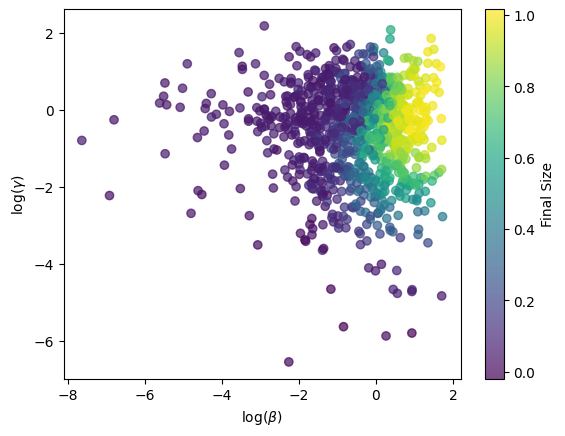

In [121]:
# plt.scatter(np.exp(x), np.exp(y), c = z, alpha=0.5, cmap="cividis")
plt.scatter(x[:1000], y[:1000], c=z[:1000], alpha=.7, cmap="viridis")
plt.xlabel(r"$\log(\beta)$")
plt.ylabel(r"$\log(\gamma)$")
plt.colorbar(label="Final Size")
plt.savefig("figures/homogeneous-sir-final-size.png")
plt.show()

# NPE

## Homogeneous

In [7]:
hom_dataset.sample_model()
train_data, val_data = random_split(hom_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=200)
val_loader = DataLoader(val_data, batch_size=b)

Simulating samples...


In [8]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = NeuralPosteriorEstimator(2, 5, 4, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 19.7 K | train
-------------------------------------------
19.7 K    Trainable params
0         Non-trainable params
19.7 K    Total params
0.079     Total estimated model params size (MB)
33        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                      | 0/? [00:00<?, ?it/s]

Training: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                           | 0/? [00:00<?, ?it/s]

Validation: |                                                           | 0/? [00:00<?, ?it/s]

...

Validation: |                                                           | 0/? [00:00<?, ?it/s]

Validation: |                                                           | 0/? [00:00<?, ?it/s]

Validation: |                                                           | 0/? [00:00<?, ?it/s]

Validation: |                                                           | 0/? [00:00<?, ?it/s]

Validation: |                                                           | 0/? [00:00<?, ?it/s]

In [9]:
I = 100
J = 100
ppe_hom = np.empty(I,)
for i in range(I):
    x_o = observed_hom[i]
    posterior = model.sample(J, x_o)
    posterior_predictive = np.empty((J, 5))
    for j in range(J):
        z = torch.exp(posterior[j])
        x = hom_dataset.simulate(z)
        posterior_predictive[j] = x
    error = ((posterior_predictive - x_o.numpy())**2).sum(1).mean(0)
    ppe_hom[i] = error
ppe_hom.mean()

np.float64(0.08996024885444445)

In [10]:
I = 100
J = 100
ppe_het = np.empty(I,)
for i in range(I):
    x_o = observed_het[i]
    posterior = model.sample(J, x_o)
    posterior_predictive = np.empty((J, 5))
    for j in range(J):
        z = torch.exp(posterior[j])
        x = hom_dataset.simulate(z)
        posterior_predictive[j] = x
    error = ((posterior_predictive - x_o.numpy())**2).sum(1).mean(0)
    ppe_het[i] = error
ppe_het.mean()

np.float64(0.27256174589161675)

## Heterogeneous

In [11]:
het_dataset.sample_model()
train_data, val_data = random_split(het_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=200)
val_loader = DataLoader(val_data, batch_size=b)

Simulating samples...


In [12]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = NeuralPosteriorEstimator(6, 5, 4, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 22.8 K | train
-------------------------------------------
22.8 K    Trainable params
0         Non-trainable params
22.8 K    Total params
0.091     Total estimated model params size (MB)
33        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                      | 0/? [00:00<?, ?it/s]

Training: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                           | 0/? [00:00<?, ?it/s]

Validation: |                                                           | 0/? [00:00<?, ?it/s]

...

Validation: |                                                           | 0/? [00:00<?, ?it/s]

Validation: |                                                           | 0/? [00:00<?, ?it/s]

Validation: |                                                           | 0/? [00:00<?, ?it/s]

Validation: |                                                           | 0/? [00:00<?, ?it/s]

Validation: |                                                           | 0/? [00:00<?, ?it/s]

In [13]:
I = 100
J = 100
ppe_hom2 = np.empty(I,)
for i in range(I):
    x_o = observed_hom[i]
    posterior = model.sample(J, x_o)
    posterior_predictive = np.empty((J, 5))
    for j in range(J):
        z = torch.exp(posterior[j])
        x = het_dataset.simulate(z)
        posterior_predictive[j] = x
    error = ((posterior_predictive - x_o.numpy())**2).sum(1).mean(0)
    ppe_hom2[i] = error
ppe_hom2.mean()

np.float64(0.11799449890020595)

In [14]:
I = 100
J = 100
ppe_het2 = np.empty(I,)
for i in range(I):
    x_o = observed_het[i]
    posterior = model.sample(J, x_o)
    posterior_predictive = np.empty((J, 5))
    for j in range(J):
        z = torch.exp(posterior[j])
        x = het_dataset.simulate(z)
        posterior_predictive[j] = x
    error = ((posterior_predictive - x_o.numpy())**2).sum(1).mean(0)
    ppe_het2[i] = error
ppe_het2.mean()

np.float64(0.14539899853142452)

# MDE

## Homogeneous Dataset

In [12]:
hom_dataset = HetSIRModel(betas = 1, gamma=1, K=5, N=100, T=10, prior_scale=[1, 1],
                     n_sample=N, observed_seed=10, mode="criticism", noise=noise)
hom_dataset.sample_model()

Simulating samples...


In [13]:
train_data, val_data = random_split(hom_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=200)
val_loader = DataLoader(val_data, batch_size=b)

In [14]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = MarginalDensityFlow(5, 4, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name | Type | Params | Mode 
--------------------------------------
0 | flow | MAF  | 20.8 K | train
--------------------------------------
20.8 K    Trainable params
0         Non-trainable params
20.8 K    Total params
0.083     Total estimated model params size (MB)
32        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                      | 0/? [00:00<?, ?it/s]

Training: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                           | 0/? [00:00<?, ?it/s]

Validation: |                                                           | 0/? [00:00<?, ?it/s]

...

Validation: |                                                           | 0/? [00:00<?, ?it/s]

Validation: |                                                           | 0/? [00:00<?, ?it/s]

Validation: |                                                           | 0/? [00:00<?, ?it/s]

Validation: |                                                           | 0/? [00:00<?, ?it/s]

Validation: |                                                           | 0/? [00:00<?, ?it/s]

In [15]:
x_val, mll_val = trainer.predict(model, val_loader)[0]
samples = model.sample(x_val.shape[0])
c2st(x_val.squeeze(1), samples)

Predicting: |                                                           | 0/? [00:00<?, ?it/s]

tensor(0.5563, dtype=torch.float64)

In [21]:
log_probs = []
p_values = []
for i in range(100):
    x_o = observed_hom[i]
    _, log_prob = model.predict_step(x_o)
    log_prob = log_prob.detach().item()
    log_probs.append(log_prob)
    p = (log_prob > mll_val).float().mean()
    p_values.append(p.item())
log_probs_00 = np.array(log_probs)
p_values_00 = np.array(p_values)

In [34]:
(p_values_00 < 0.05).mean()

np.float64(0.01)

In [32]:
log_probs = []
p_values = []
for i in range(100):
    x_o = observed_het[i]
    _, log_prob = model.predict_step(x_o)
    log_prob = log_prob.detach().item()
    log_probs.append(log_prob)
    p = (log_prob > mll_val).float().mean()
    p_values.append(p.item())
log_probs_01 = np.array(log_probs)
p_values_01 = np.array(p_values)

In [35]:
(p_values_01 < 0.05).mean()

np.float64(0.57)

## Heterogeneous Dataset

In [60]:
het_dataset = HetSIRModel(betas= [0.67, 1, 1.5, 2.25, 3], gamma=1, K=5, N=200, T=10, prior_scale=[1, 1, 1, 1, 1, 1],
                     n_sample=N, observed_seed=10, mode="criticism", noise=noise)
het_dataset.sample_model()
train_data, val_data = random_split(het_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=200)
val_loader = DataLoader(val_data, batch_size=b)

Simulating samples...


In [61]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = MarginalDensityFlow(5, 4, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name | Type | Params | Mode 
--------------------------------------
0 | flow | MAF  | 20.8 K | train
--------------------------------------
20.8 K    Trainable params
0         Non-trainable params
20.8 K    Total params
0.083     Total estimated model params size (MB)
32        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                      | 0/? [00:00<?, ?it/s]

Training: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                           | 0/? [00:00<?, ?it/s]

Validation: |                                                           | 0/? [00:00<?, ?it/s]

...

Validation: |                                                           | 0/? [00:00<?, ?it/s]

Validation: |                                                           | 0/? [00:00<?, ?it/s]

Validation: |                                                           | 0/? [00:00<?, ?it/s]

Validation: |                                                           | 0/? [00:00<?, ?it/s]

Validation: |                                                           | 0/? [00:00<?, ?it/s]

In [62]:
x_val, mll_val = trainer.predict(model, val_loader)[0]
samples = model.sample(x_val.shape[0])
c2st(x_val.squeeze(1), samples)

Predicting: |                                                           | 0/? [00:00<?, ?it/s]

tensor(0.5162, dtype=torch.float64)

In [63]:
log_probs = []
p_values = []
for i in range(100):
    x_o = observed_hom[i]
    _, log_prob = model.predict_step(x_o)
    log_prob = log_prob.detach().item()
    log_probs.append(log_prob)
    p = (log_prob > mll_val).float().mean()
    p_values.append(p.item())
log_probs_10 = np.array(log_probs)
p_values_10 = np.array(p_values)

In [64]:
(p_values_10 < 0.05).mean()

np.float64(0.08)

In [65]:
log_probs = []
p_values = []
for i in range(100):
    x_o = observed_het[i]
    _, log_prob = model.predict_step(x_o)
    log_prob = log_prob.detach().item()
    log_probs.append(log_prob)
    p = (log_prob > mll_val).float().mean()
    p_values.append(p.item())
log_probs_11 = np.array(log_probs)
p_values_11 = np.array(p_values)

In [66]:
(p_values_11 < 0.05).mean()

np.float64(0.04)

## Bayes Factor Analysis

In [72]:
((log_probs_00 - log_probs_10) > logK[1]).mean()

np.float64(0.58)

In [73]:
((log_probs_10 - log_probs_00) > logK[1]).mean()

np.float64(0.04)

In [75]:
((log_probs_11 - log_probs_01) > logK[1]).mean()

np.float64(0.65)

In [76]:
((log_probs_01 - log_probs_11) > logK[1]).mean()

np.float64(0.06)